<a href="https://colab.research.google.com/github/ashhwiithac22/Deep-Learning-Experiments/blob/main/DL_Ex13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


First few values from dataset:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0775
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0472 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0247 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0147 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0132 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0136 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0120 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0106 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0100 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0087 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0081 
Epoch 13/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0

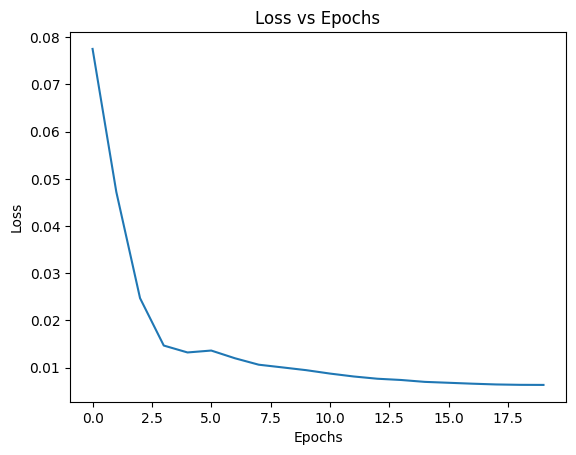

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step

RMSE: 85.16
Model Accuracy: 80.67 %

Enter last 3 passenger values (continuous values):
Value 1: 78
Value 2: 56
Value 3: 89
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step

Predicted Next Passenger Value: 107


In [ ]:
'''
LSTM is used to learn patterns from sequential data like time series, text or speech. LSTM is a special type of RNN that can remember important information for a long time
LSTM is used for time series prediction, sentiment analysis, speech recognition.
'''
import numpy as np #used for numerical operation
import pandas as pd #used for data analysis
import tensorflow as tf #tensorflow is deep learning library
import matplotlib.pyplot as plt #used for data visualisation
from sklearn.preprocessing import MinMaxScaler #used for data preprocessing
from sklearn.metrics import mean_squared_error #used to measure prediction error

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv" #stores the link of the dataset
data = pd.read_csv(url) #reads the CSV file
print("\nFirst few values from dataset:")
print(data.head())

values = data['Passengers'].values.reshape(-1,1) #converts into 2D format
scaler = MinMaxScaler(feature_range=(0,1)) #keeps values between 0 and 1
values = scaler.fit_transform(values)

def create_dataset(dataset, time_step=3):
    X, y = [], [] #creates empty lists
    for i in range(len(dataset)-time_step-1): #loops run through dataset and ensure we do not go out of range
        X.append(dataset[i:(i+time_step),0]) #takes 3 consecutive values and this becomes as input
        y.append(dataset[i+time_step,0]) #takes next value after input
    return np.array(X), np.array(y)
time_step = 3 #uses previous 3 values to predict next value

X, y = create_dataset(values, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1) #STM needs 3D input
train_size = int(len(X)*0.8) #takes 80% for training and 20% for testing

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

model = tf.keras.Sequential([tf.keras.layers.Input(shape=(time_step,1)),tf.keras.layers.LSTM(50),tf.keras.layers.Dense(1)]) #LSTM with 50 neurons peforms better and dense(1) provides one output
model.compile(optimizer='adam', loss='mse') #adam optimizer control how model learns and updates weights automatically
history = model.fit(X_train,y_train,epochs=20,batch_size=16,verbose=1)
plt.plot(history.history['loss'])
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions) #convert normalized values to original value
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions)) #calcuates root mean squared error
accuracy = 100 - (rmse / np.mean(y_test_actual)) * 100

print("\nRMSE:", round(rmse,2)) #displays RMSE value
print("Model Accuracy:", round(accuracy,2), "%") #displays accuracy
print("\nEnter last 3 passenger values (continuous values):")
v1 = float(input("Value 1: "))
v2 = float(input("Value 2: "))
v3 = float(input("Value 3: "))

user_values = np.array([[v1],[v2],[v3]]) #converts user values into numpy array
user_values = scaler.transform(user_values) #converts into 0 to 1 range
user_values = user_values.reshape(1,3,1)
pred = model.predict(user_values)
predicted_value = scaler.inverse_transform(pred)
print("\nPredicted Next Passenger Value:", int(predicted_value[0][0])) #selects 1st row 1st column